# Energy Thief — Level 1: Tabular Q-Learning

**Project VFA-4.** A thief moves on a small grid modelling a power grid, siphons
energy into an *unbanked surplus*, and must reach the **exit** to cash out
before a monitoring **alarm** wipes the surplus.


### MDP
- **State**: `(position, surplus)` encoded as a single integer → `225` states.
- **Actions**: `up, down, left, right, siphon-low, siphon-high` (6).
- **Reward**: `0` on ordinary steps; `+surplus` on reaching the exit (cash out,
  terminal); `-alarm_penalty` when an alarm fires (surplus reset to 0).
- **Dynamics**: `siphon-high` steals double but is 4× more likely to trip the
  alarm (`p_high=0.20` vs `p_low=0.05`). Episode truncates after `max_steps`.

The value map is **fixed for the whole run**, so the thief can *memorise* where
the rich cells are — exactly the regime where a Q-table works.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so the energy_thief package is importable

import numpy as np
import matplotlib.pyplot as plt

from energy_thief.envs import GridThiefEnv
from energy_thief.agents import QLearningAgent

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

In [2]:
env = GridThiefEnv(seed=42)
print(f"states: {env.n_states}   actions: {env.action_space.n}")
print(f"start: {env.start_pos}   exit: {env.exit_pos}")
print(env.render())

states: 225   actions: 6
start: (0, 0)   exit: (4, 4)
t=0  surplus=0/8
A . 2 . .
. . . . .
2 . . . 2
. 1 . . .
. . . 2 E


## Training loop

One episode = one heist. We train with $\varepsilon$-greedy exploration and
anneal $\varepsilon$ over episodes. We repeat over several seeds to get a
learning curve with a variance band, as required by the experimental protocol.

In [3]:
def train(env, n_episodes, seed, **kw):
    agent = QLearningAgent(env.n_states, env.action_space.n, seed=seed, **kw)
    returns = np.empty(n_episodes)
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, g = False, 0.0
        while not done:
            a = agent.select_action(s)
            s2, r, term, trunc, _ = env.step(a)
            agent.update(s, a, r, s2, term)
            s, g, done = s2, g + r, term or trunc
        agent.end_episode()
        returns[ep] = g
    return agent, returns


def evaluate(env, agent, n_episodes=1000):
    rets = np.empty(n_episodes)
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, g = False, 0.0
        while not done:
            a = agent.select_action(s, greedy=True)
            s, r, term, trunc, _ = env.step(a)
            g, done = g + r, term or trunc
        rets[ep] = g
    return rets.mean(), rets.std()

In [4]:
N_EPISODES = 10000
SEEDS = range(5)
HP = dict(alpha=0.1, gamma=0.99, epsilon_decay=0.999)

curves, agents = [], []
for seed in SEEDS:
    agent, returns = train(GridThiefEnv(seed=42), N_EPISODES, seed=seed, **HP)
    curves.append(returns)
    agents.append(agent)
curves = np.array(curves)
print("training done:", curves.shape)

training done: (5, 10000)


## Learning curve

Return per episode, averaged over seeds (shaded band = ±1 std). A moving average
smooths the $\varepsilon$-greedy noise so the trend is readable.

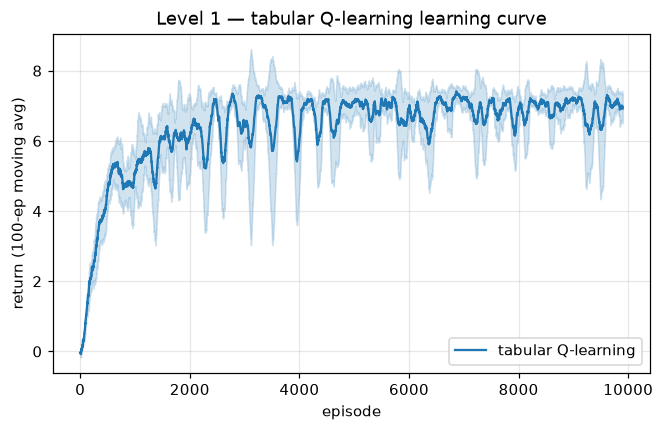

In [5]:
def moving_average(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode="valid")

smoothed = np.array([moving_average(c) for c in curves])
mean, std = smoothed.mean(0), smoothed.std(0)
x = np.arange(smoothed.shape[1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, mean, color="C0", label="tabular Q-learning")
ax.fill_between(x, mean - std, mean + std, color="C0", alpha=0.2)
ax.set_xlabel("episode"); ax.set_ylabel("return (100-ep moving avg)")
ax.set_title("Level 1 — tabular Q-learning learning curve")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## Evaluation vs baselines

We compare the trained greedy policy against a **random** agent and the
**hand-coded heuristic** (siphon if the cell is rich, else walk to the exit).

In [6]:
def baseline_random(env, n=1000):
    r = np.empty(n)
    for i in range(n):
        s, _ = env.reset(); done, g = False, 0.0
        while not done:
            a = int(rng.integers(env.action_space.n))
            s, rr, term, trunc, _ = env.step(a); g += rr; done = term or trunc
        r[i] = g
    return r.mean(), r.std()

def baseline_heuristic(env, n=1000):
    r = np.empty(n)
    for i in range(n):
        s, _ = env.reset(); done, g = False, 0.0
        while not done:
            (row, col), surplus = env.decode(s)
            if env.value_map[row, col] > 0 and surplus < env.surplus_max:
                a = 4
            else:
                er, ec = env.exit_pos
                a = 1 if row < er else 3
            s, rr, term, trunc, _ = env.step(a); g += rr; done = term or trunc
        r[i] = g
    return r.mean(), r.std()

eval_env = GridThiefEnv(seed=42)
rand_m, rand_s = baseline_random(eval_env)
heur_m, heur_s = baseline_heuristic(eval_env)
q_scores = [evaluate(eval_env, ag) for ag in agents]
q_m = np.mean([m for m, _ in q_scores]); q_s = np.mean([s for _, s in q_scores])

for name, (m, sd) in [("random", (rand_m, rand_s)),
                      ("heuristic", (heur_m, heur_s)),
                      ("Q-learning", (q_m, q_s))]:
    print(f"{name:12s} {m:+.2f} ± {sd:.2f}")

random       -0.06 ± 2.35
heuristic    +7.54 ± 1.03
Q-learning   +7.38 ± 1.28


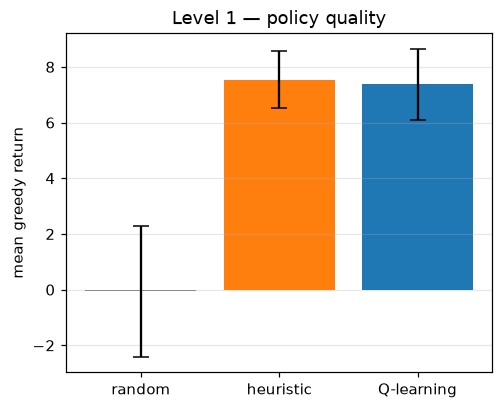

In [7]:
labels = ["random", "heuristic", "Q-learning"]
means = [rand_m, heur_m, q_m]
errs = [rand_s, heur_s, q_s]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(labels, means, yerr=errs, capsize=5, color=["C7", "C1", "C0"])
ax.set_ylabel("mean greedy return"); ax.set_title("Level 1 — policy quality")
ax.grid(axis="y", alpha=0.3)
plt.show()

## What the thief learned

One greedy rollout, drawn on the grid: rich cells shaded, the path in blue, and
siphon steps marked. This makes the learned strategy legible — one of the
selling points of a tabular value function.

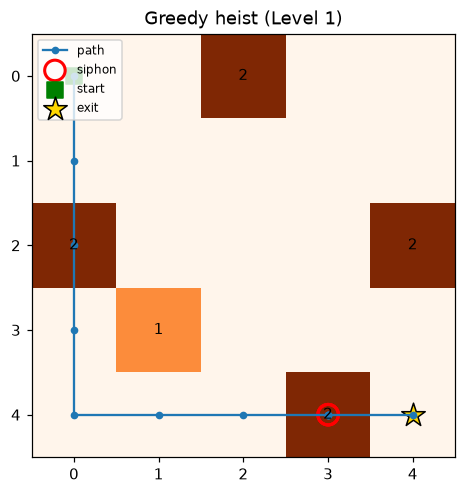

In [8]:
def greedy_rollout(env, agent):
    s, _ = env.reset()
    path, siphons = [env.pos], []
    done = False
    while not done:
        a = agent.select_action(s, greedy=True)
        s, r, term, trunc, info = env.step(a)
        path.append(env.pos)
        if info["siphoned"] > 0:
            siphons.append(env.pos)
        done = term or trunc
    return path, siphons

path, siphons = greedy_rollout(GridThiefEnv(seed=42), agents[0])

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(env.value_map, cmap="Oranges", origin="upper")
for (r, c), v in np.ndenumerate(env.value_map):
    if v > 0:
        ax.text(c, r, str(v), ha="center", va="center", color="black")
ys, xs = zip(*path)
ax.plot(xs, ys, "-o", color="C0", ms=4, lw=1.5, label="path")
if siphons:
    sy, sx = zip(*siphons)
    ax.scatter(sx, sy, s=180, facecolors="none", edgecolors="red", lw=2, label="siphon")
sr, sc = env.start_pos; er, ec = env.exit_pos
ax.scatter([sc], [sr], marker="s", s=120, color="green", label="start")
ax.scatter([ec], [er], marker="*", s=260, color="gold", edgecolors="k", label="exit")
ax.set_xticks(range(env.size)); ax.set_yticks(range(env.size))
ax.set_title("Greedy heist (Level 1)"); ax.legend(loc="upper left", fontsize=8)
plt.show()

## Takeaways

- Tabular Q-learning solves Level 1: it climbs from the random baseline to match
  (and refine on) the hand-coded heuristic, using the alarm/reward signal alone.
- It works **because the state space is tiny (225 states) and fixed**, so every
  `(position, surplus)` pair is visited enough to estimate `Q` directly.
- **Next (Level 2):** enlarge the grid and add per-cell *heat* (adaptive
  monitoring). The state space explodes and the table stops fitting in memory /
  stops being visited enough — motivating **linear function approximation**.